# Lab 01 - Classifying Spam Emails

Notebook này đi theo flow phân tích rõ ràng từ data đến model:

1. **Raw data thế nào?** Load raw/processed data, EDA trên raw: missing, duplicate, label/source distribution.
2. **Clean và preprocess.** Làm sạch text, tạo feature `clean_text`, kiểm tra missing/duplicate sau preprocess, EDA trên data clean nhưng **chưa balance**.
3. **Balance data.** Downsample để ham/spam cân bằng, EDA sau balance.
4. **Bổ sung ham data v2.** Load thêm ham từ `data_v2`, EDA nguồn mới trước khi đưa vào train.
5. **Chia dataset.** Cố định một test set từ data v1 clean/unbalanced; data v2 chỉ được thêm vào train để tránh leakage.
6. **Train 9 phiên bản.** 3 training datasets (`Balanced`, `Unbalanced`, `V2 merged`) x 3 model (`Naive Bayes`, `Logistic Regression`, `Linear SVM`), vẽ 9 confusion matrices.
7. **Tính metric chính.** In `TP`, `FP`, `TN`, `FN`, `precision`, `recall/TPR`, `FPR`, `FNR`, `TNR`, `accuracy`, và assert lại công thức.
8. **Check lại với sklearn.** So sánh bản from-scratch với sklearn trên sample để kiểm tra logic.
9. **Threshold tuning.** Chọn threshold trên validation theo mục tiêu `TPR ~ 99%` và `FPR ~ 1%`, sau đó chỉ báo cáo cuối trên test.
10. **Failure analysis.** Phân tích vì sao chưa đạt 99/1 và issue nằm ở data/feature/model nào.


## Step 0 — Import Libraries And Setup


In [33]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for module_path in [NOTEBOOKS_DIR, PROJECT_ROOT]:
    module_path = str(module_path)
    if module_path in sys.path:
        sys.path.remove(module_path)
    sys.path.insert(0, module_path)

import crawl
import preprocess
import model_from_scratch
import eda
import utils

crawl = importlib.reload(crawl)
preprocess = importlib.reload(preprocess)
model_from_scratch = importlib.reload(model_from_scratch)
eda = importlib.reload(eda)
utils = importlib.reload(utils)
model_checker = model_from_scratch.SklearnModelChecker()

paths = crawl.project_paths(PROJECT_ROOT)
print(f"crawl module: {crawl.__file__}")
print(f"preprocess module: {preprocess.__file__}")
print(f"model module: {model_from_scratch.__file__}")
print(f"eda module: {eda.__file__}")
print(f"utils module: {utils.__file__}")
PROJECT_ROOT

crawl module: /Users/quangmanh/Project/lab01/notebooks/crawl.py
preprocess module: /Users/quangmanh/Project/lab01/notebooks/preprocess.py
model module: /Users/quangmanh/Project/lab01/notebooks/model_from_scratch.py
eda module: /Users/quangmanh/Project/lab01/notebooks/eda.py


PosixPath('/Users/quangmanh/Project/lab01')

## Step 1 — Raw Data Overview And Raw EDA

Load dữ liệu raw và file processed hiện có để đối chiếu. Step này trả lời: raw data có bao nhiêu dòng, phân phối label/source thế nào, có missing/duplicate không.


In [34]:
data, raw_data, paths = crawl.load_datasets(PROJECT_ROOT)
processed_data = data.copy().reset_index(drop=True)
overview = crawl.dataset_overview(processed_data, raw_data)

print(f"Processed rows: {overview['processed_rows']:,}")
print(f"Raw rows: {overview['raw_rows']:,}" if overview["raw_rows"] else "Raw dataset not found")
display(processed_data.head(3))

Processed rows: 9,886
Raw rows: 18,807


,email_id,source,source_family,source_url,local_path,extracted_from,extracted_path,archive_path,label,sender,recipient,subject,body,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,71d2056787e4c1e3e1c5b4902fc41127243bbf63c778ed...,huggingface_enron_spam,huggingface_enron_spam,SetFit/enron_spam,SetFit/enron_spam,huggingface,train/539,train/539,ham,,,,membership mixer tomorrow - paesanos lounge ! ...,membership mixer tomorrow - paesanos lounge !...,membership mixer tomorrow paesanos lounge nesa...,1349,799,112
1,493bcce942bedc9f6f624788fe981c0ca0684bf066ae48...,aueb_enron1_spam_ham,aueb_enron1_spam_ham,https://www2.aueb.gr/users/ion/data/enron-spam...,/Users/quangmanh/Project/lab01/data/raw/downlo...,/Users/quangmanh/Project/lab01/data/raw/downlo...,enron1/spam/1204.2004-05-25.GP.spam.txt,enron1/spam/1204.2004-05-25.GP.spam.txt,spam,,,", si , ze does - matt ` er ; no r "" eally ^ fy...","hey , my girlfriend bought me these penls pil ...",", si , ze does - matt ` er ; no r "" eally ^ fy...",si ze does matt er eally fyjlxqcbp hey girlfri...,386,187,29
2,f9a91ae7262fc1af4c7cada985dd975afa560b73cc020d...,huggingface_enron_spam,huggingface_enron_spam,SetFit/enron_spam,SetFit/enron_spam,huggingface,train/499,train/499,ham,,,,fw : ercot lse ' s this is some fun stuff\n- -...,fw : ercot lse ' s this is some fun stuff\n- ...,ercot lse fun stuff original message presto ke...,4810,2705,374


In [35]:
if raw_data.empty:
    print("Raw dataset not found; only processed dataset is available.")
    data.info()
else:
    raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18807 entries, 0 to 18806
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   email_id        18807 non-null  object
 1   source          18807 non-null  object
 2   source_family   18807 non-null  object
 3   source_url      18807 non-null  object
 4   local_path      18807 non-null  object
 5   extracted_from  18807 non-null  object
 6   extracted_path  18807 non-null  object
 7   archive_path    18807 non-null  object
 8   label           18807 non-null  object
 9   sender          18807 non-null  object
 10  recipient       18807 non-null  object
 11  subject         18807 non-null  object
 12  body            18807 non-null  object
 13  text            18807 non-null  object
dtypes: object(14)
memory usage: 2.0+ MB


### Step 1.1 — Raw Missing Data Check

Đếm số giá trị missing theo từng cột của raw dataset và visualize để kiểm tra chất lượng dữ liệu trước preprocessing.


,column,missing_count,missing_percent,dtype
0,archive_path,0,0.0,object
1,body,0,0.0,object
2,email_id,0,0.0,object
3,extracted_from,0,0.0,object
4,extracted_path,0,0.0,object
5,label,0,0.0,object
6,local_path,0,0.0,object
7,recipient,0,0.0,object
8,sender,0,0.0,object
9,source,0,0.0,object


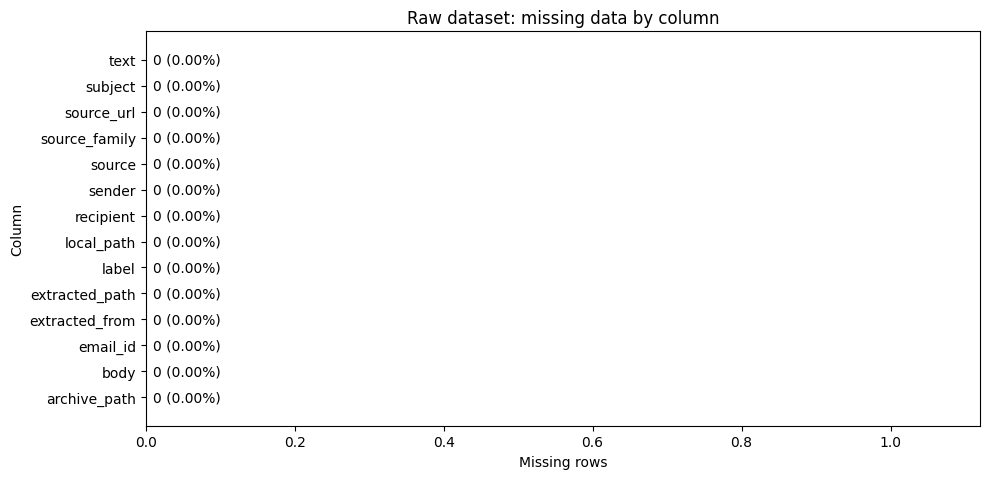

In [36]:
missing_summary = preprocess.missing_data_summary(raw_data)
display(missing_summary)
preprocess.plot_missing_data(raw_data, title="Raw dataset: missing data by column")

### Step 1.2 — Raw Duplicate Rows Check

Đếm số dòng duplicate trong raw dataset và visualize tỉ lệ unique/duplicate trước preprocessing.


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,all columns,18807,18807,0,0.0


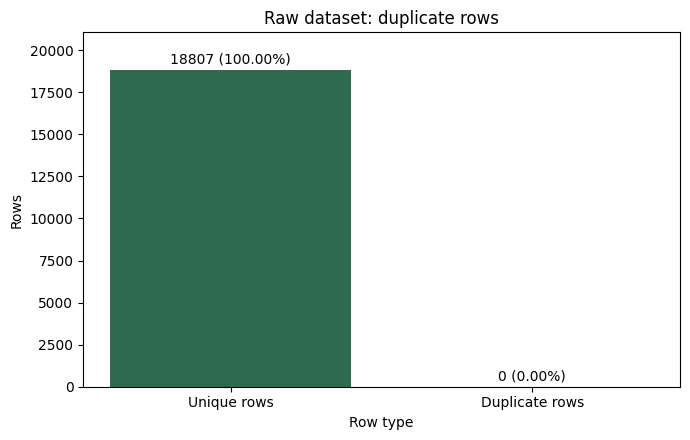

In [37]:
duplicate_summary = preprocess.duplicate_data_summary(raw_data)
display(duplicate_summary)
preprocess.plot_duplicate_data(raw_data, title="Raw dataset: duplicate rows")

### Step 1.3 — Raw Label And Source Distribution


In [38]:
raw_eda_frame = raw_data if not raw_data.empty else data
display(crawl.label_counts(raw_eda_frame))
display(crawl.source_counts(raw_eda_frame, top_n=15))

,label,rows
0,ham,13616
1,spam,5191


,source_family,rows
0,spamassassin,5187
1,kaggle_enron_email_dataset,5000
2,kaggle_email_spam_classification,1000
3,aueb_enron3_spam_ham,999
4,huggingface_enron_spam,996
5,aueb_enron2_spam_ham,995
6,aueb_enron1_spam_ham,992
7,huggingface_kimdongh_spam_dataset,981
8,aueb_enron4_spam_ham,963
9,aueb_enron6_spam_ham,925


## Step 2 — Clean And Preprocess Text

Tạo `clean_text`, lọc các dòng trainable, giữ bản **unbalanced** để nhìn đúng phân phối tự nhiên trước khi balance. Step này cũng check missing/duplicate sau preprocess ở các feature dùng để train.


In [39]:
display(preprocess.processed_sample(data, rows=3, random_state=42))

,label,source_family,subject,body,clean_text
4170,spam,aueb_enron2_spam_ham,undeliverable : home based business for grownups,your message\r\nsubject : home based business ...,undeliverable home based business grownups mes...
5809,ham,spamassassin,Re: [ILUG] SUSE 8 disks? (thread changed sligh...,wintermute <cout@eircom.net> a écrit:\n\n\n> >...,ilug suse disks thread changed slightly winter...
3023,ham,kaggle_enron_email_dataset,,Message-ID: <15581064.1075855710484.JavaMail.e...,message-id javamail evans thyme tue mar pst mi...


In [40]:
raw_example, clean_example = preprocess.example_cleaning()

print("Raw example:")
print(raw_example)
print("\nCleaned example using notebooks/preprocess.py:")
print(clean_example)

Raw example:
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>

Cleaned example using notebooks/preprocess.py:
win money claim today


### Step 2.1 — Raw-To-Clean Check On Real Rows

Cell này chứng minh preprocessing chạy trên dữ liệu raw thật, không chỉ trên ví dụ tự tạo.


In [41]:
raw_to_clean = preprocess.raw_to_clean_sample(raw_data, rows=5)
if raw_to_clean.empty:
    print("Raw dataset is not available, so this check is skipped.")
else:
    display(raw_to_clean)

,label,source_family,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,ham,spamassassin,RE: The Curse of India's Socialism > From: for...,curse india's socialism behalf james rogers cu...,1601,846,114
1,ham,spamassassin,"Re: ARRRGHHH Had GPG working, now it doesnt. H...",arrrghhh gpg working doesnt hi sun sep mdt reg...,987,460,69
2,ham,spamassassin,Re: bad focus/click behaviours On Fri Sep 13 2...,bad focus behaviours fri sep robert elz wrote ...,1527,674,102
3,ham,spamassassin,"Re: ALSA (almost) made easy On Thu, 2002-08-29...",alsa easy thu matthias saou wrote thanks lot r...,1442,699,108
4,ham,spamassassin,creating rpms with subdirs (install command) H...,creating rpms subdirs install command hi i'm b...,803,365,53


### Step 2.2 — EDA After Preprocess, Before Balance

Đây là data đã clean và lọc trainable nhưng **chưa cân bằng**. Đây là baseline phân phối thật của data v1.


In [42]:
full_clean_data, before_balance_data, unbalanced_processed_data = utils.run_preprocess_step(raw_data)

Full cleaned rows: 18,323
Trainable rows after preprocess, before balance: 12,960
Unbalanced label counts


,label,rows
0,ham,8291
1,spam,4669


After preprocess, before balance: missing data in model/features columns


,column,missing_count,missing_percent,dtype
0,clean_char_count,0,0.0,int64
1,clean_text,0,0.0,object
2,clean_word_count,0,0.0,int64
3,label,0,0.0,object
4,raw_char_count,0,0.0,int64
5,source_family,0,0.0,object
6,subject,0,0.0,object
7,text,0,0.0,object


After preprocess, before balance: duplicate clean_text + label


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,"clean_text, label",12960,12960,0,0.0


label,source_family,ham,spam,total,spam_rate
9,spamassassin,4091,668,4759,0.1404
2,aueb_enron3_spam_ham,493,494,987,0.5005
8,kaggle_email_spam_classification,437,547,984,0.5559
1,aueb_enron2_spam_ham,490,488,978,0.4990
0,aueb_enron1_spam_ham,491,456,947,0.4815
3,aueb_enron4_spam_ham,492,444,936,0.4744
7,huggingface_kimdongh_spam_dataset,471,446,917,0.4864
5,aueb_enron6_spam_ham,480,423,903,0.4684
6,huggingface_enron_spam,384,404,788,0.5127
4,aueb_enron5_spam_ham,462,299,761,0.3929


,analysis_char_count,analysis_word_count,subject_chars
count,12960.000000,12960.000000,12960.000000
mean,924.435802,124.972685,28.440895
std,2435.276217,286.998275,24.190895
min,25.000000,5.000000,0.000000
25%,239.750000,34.000000,10.000000
50%,474.500000,68.000000,27.000000
75%,942.000000,132.000000,42.000000
95%,2824.100000,379.050000,68.000000
max,120772.000000,15414.000000,452.000000


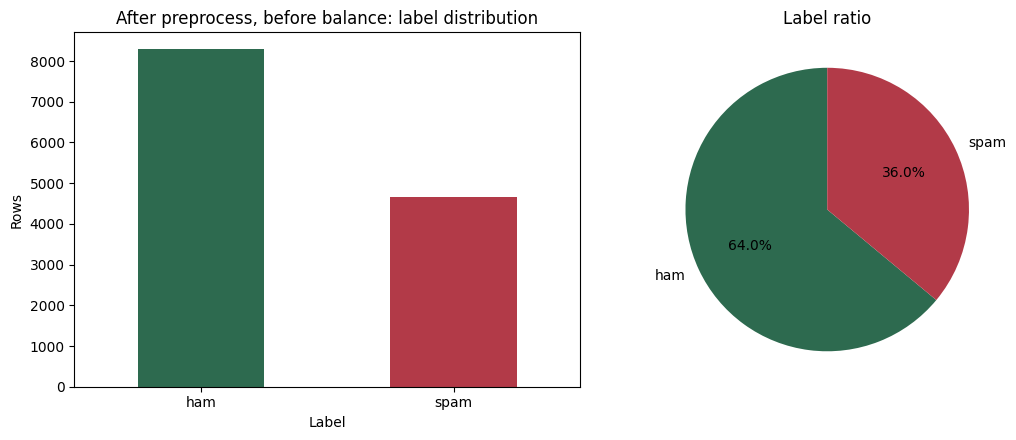

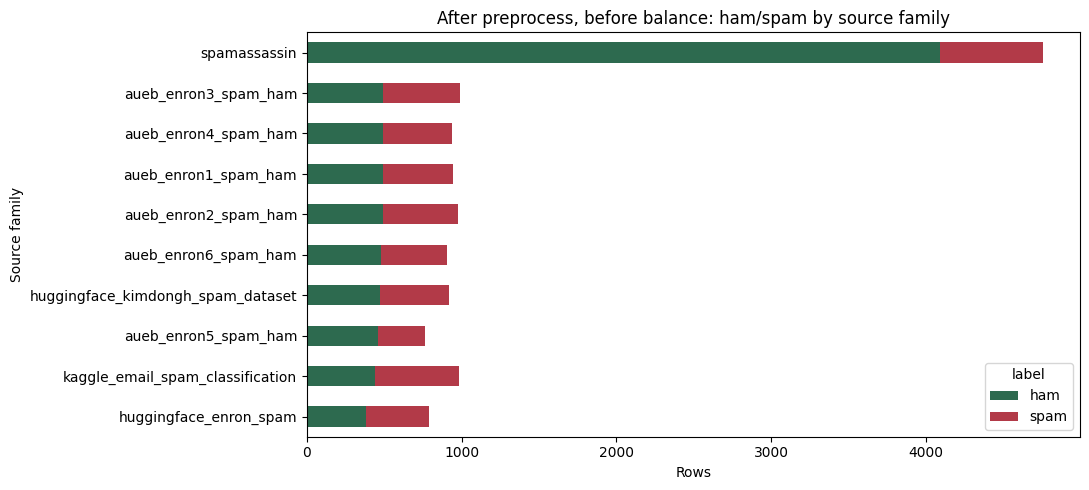

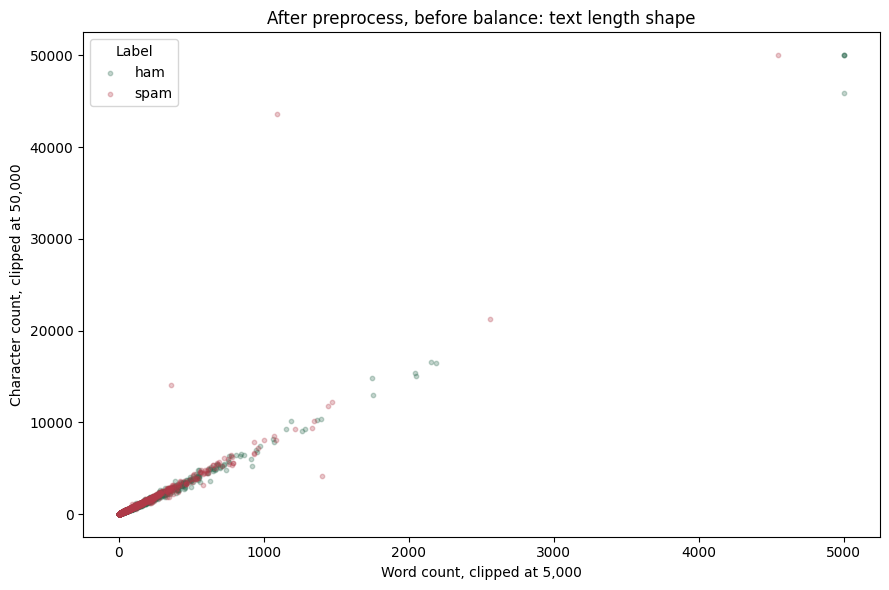

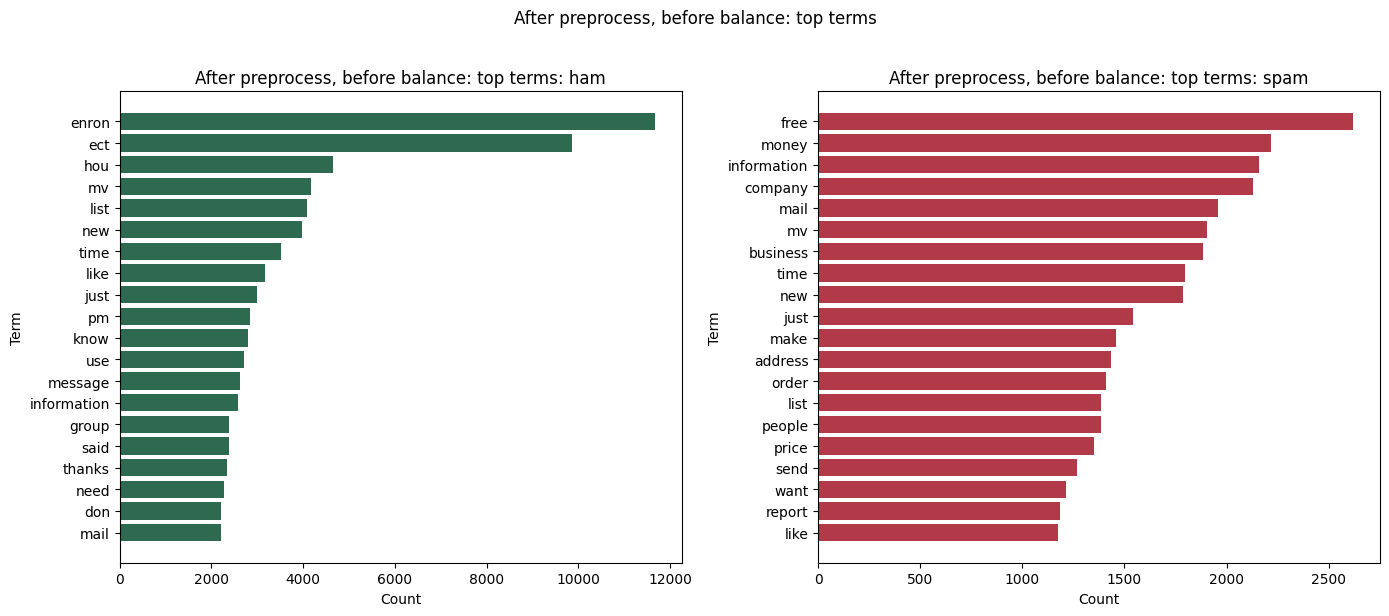

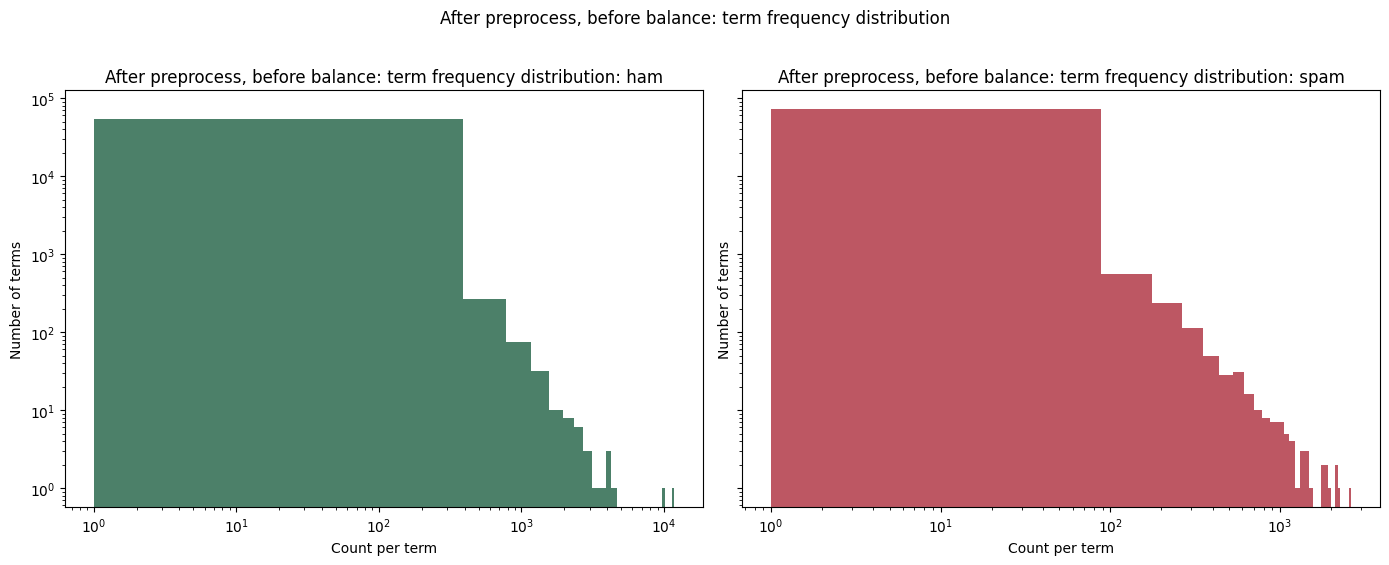

In [43]:
eda = importlib.reload(eda)
eda.plot_eda_overview(before_balance_data, title_prefix="After preprocess, before balance")

## Step 3 — Balance Data And EDA

Downsample ham/spam trong trainable data để tạo bản cân bằng. Step này dùng để xem balance thay đổi phân phối label/source/text như thế nào.


In [44]:
balanced_data = preprocess.balance_dataset(before_balance_data, random_seed=42)

print(f"Before balance rows: {len(before_balance_data):,}")
print(f"Balanced rows: {len(balanced_data):,}")
print("Before balance label counts")
display(crawl.label_counts(before_balance_data))
print("After balance label counts")
display(crawl.label_counts(balanced_data))
display(eda.source_label_table(balanced_data).head(20))
display(eda.length_summary(balanced_data))

Before balance rows: 12,960
Balanced rows: 9,002
Before balance label counts


,label,rows
0,ham,8291
1,spam,4669


After balance label counts


,label,rows
0,ham,4501
1,spam,4501


label,source_family,ham,spam,total,spam_rate
8,kaggle_email_spam_classification,437,547,984,0.5559
9,spamassassin,460,500,960,0.5208
2,aueb_enron3_spam_ham,460,494,954,0.5178
1,aueb_enron2_spam_ham,460,488,948,0.5148
0,aueb_enron1_spam_ham,460,456,916,0.4978
7,huggingface_kimdongh_spam_dataset,460,446,906,0.4923
3,aueb_enron4_spam_ham,460,444,904,0.4912
5,aueb_enron6_spam_ham,460,423,883,0.4790
6,huggingface_enron_spam,384,404,788,0.5127
4,aueb_enron5_spam_ham,460,299,759,0.3939


,analysis_char_count,analysis_word_count,subject_chars
count,9002.000000,9002.000000,9002.000000
mean,930.903244,125.043657,24.585425
std,2457.019088,281.331753,25.115546
min,25.000000,5.000000,0.000000
25%,230.000000,33.000000,0.000000
50%,472.000000,67.000000,22.000000
75%,1009.000000,139.000000,38.000000
95%,2859.900000,382.950000,67.000000
max,120772.000000,15414.000000,452.000000


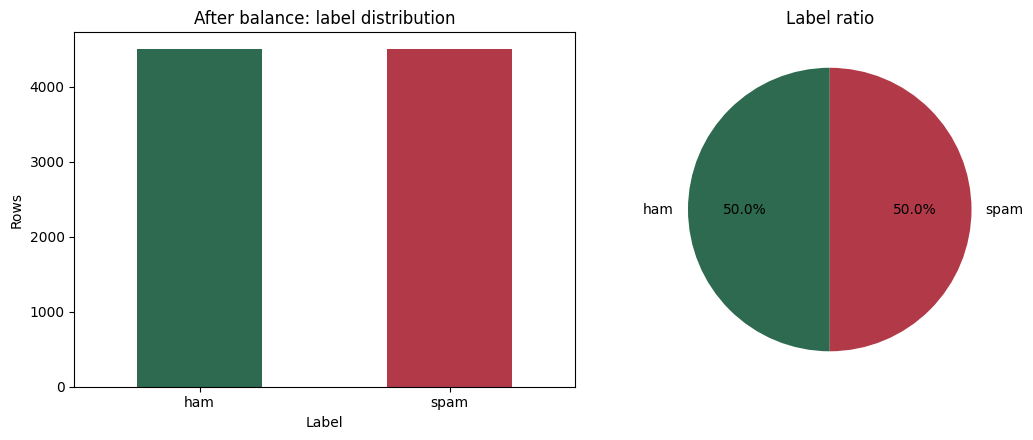

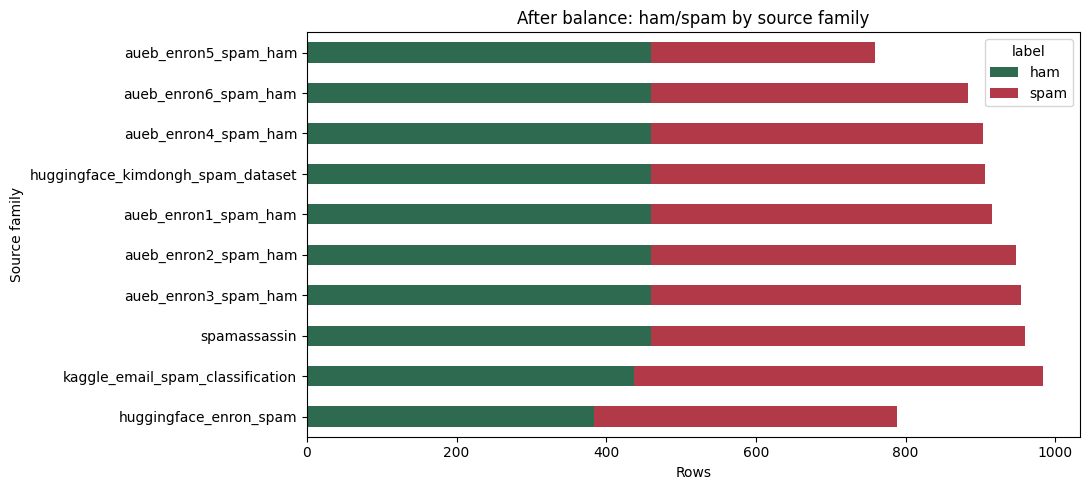

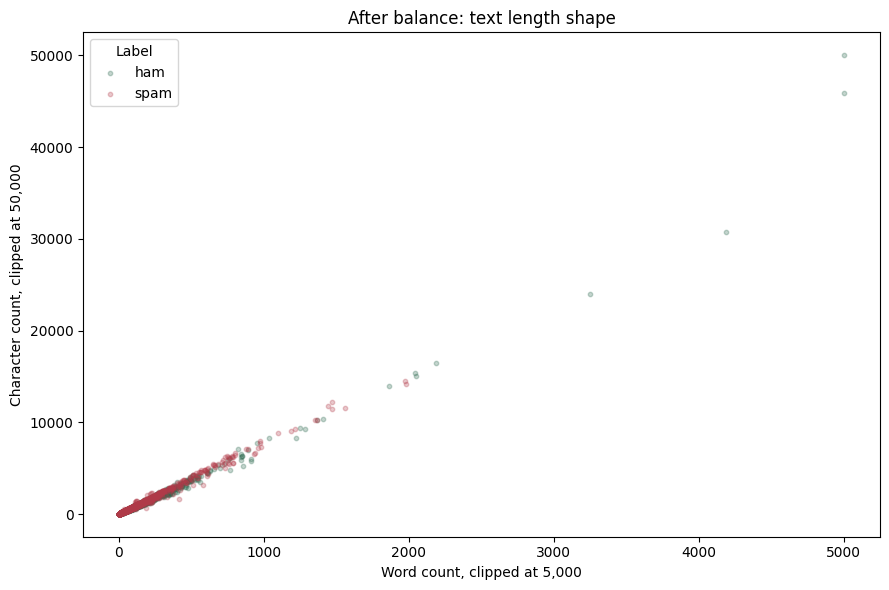

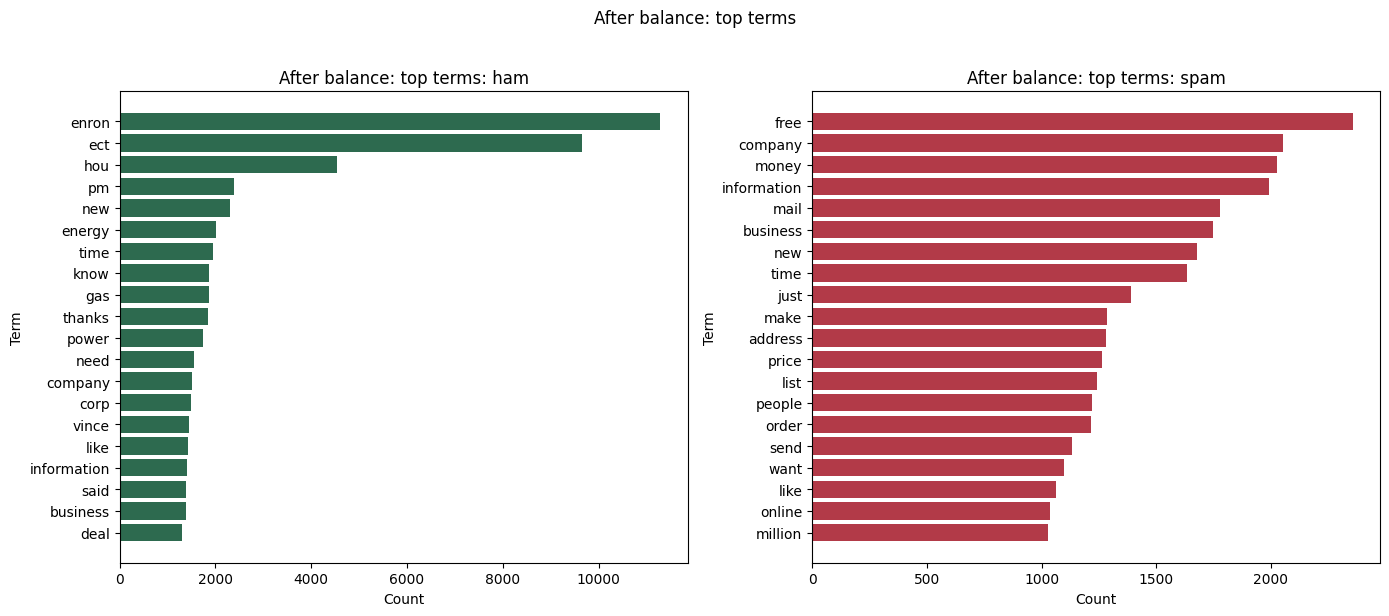

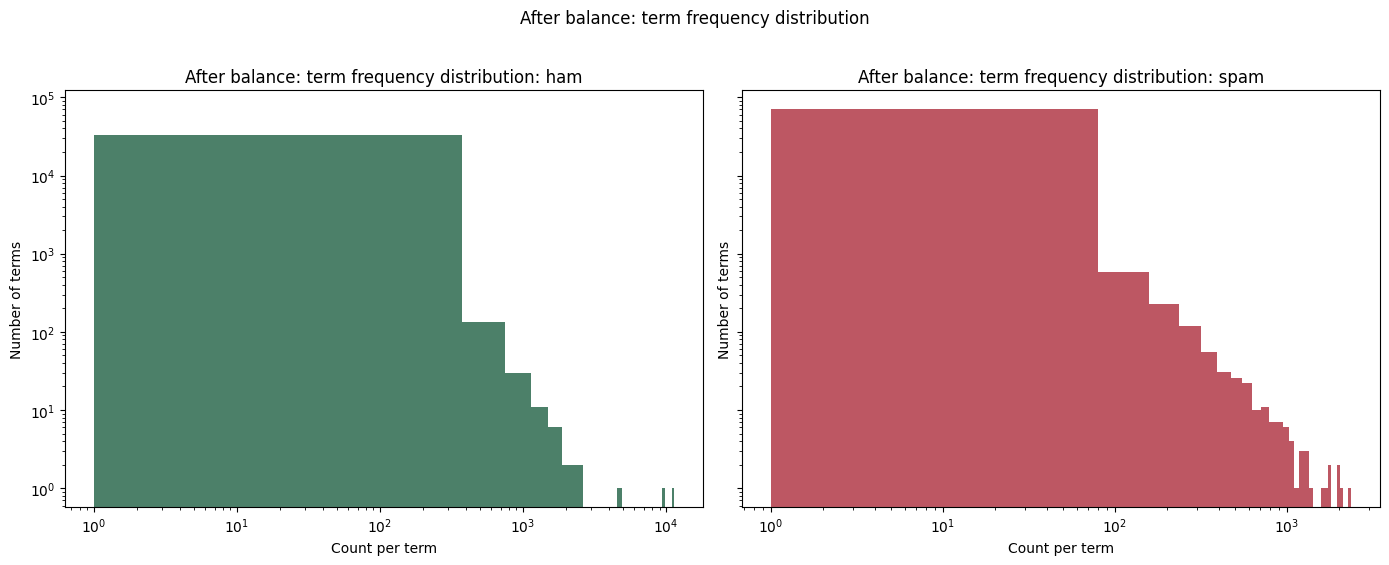

In [45]:
eda = importlib.reload(eda)
eda.plot_eda_overview(balanced_data, title_prefix="After balance")

### Step 3 Notes — EDA Reading

So sánh Step 2 và Step 3 để thấy trade-off của downsample balance: data cân bằng hơn, nhưng có thể mất bớt biến thể ham. Đây là lý do các bước sau luôn test `Balanced`, `Unbalanced`, và `V2 merged` trên cùng một test set.


## Step 4 — Add Ham Data V2 And EDA

Load thêm ham từ `data_v2/processed/emails.csv`. Step này chỉ EDA nguồn ham mới; khi train, data v2 chỉ được ghép vào train set, không được chạm vào test set.


Data v2 rows after preprocess filter: 5,934


,label,rows
0,ham,5934


,source_family,rows
0,v2_kaggle_enron_email_dataset,4943
1,v2_spamassassin_20030228_easy_ham_2,991


label,source_family,ham,spam,total,spam_rate
0,v2_kaggle_enron_email_dataset,4943,0,4943,0.0
1,v2_spamassassin_20030228_easy_ham_2,991,0,991,0.0


,analysis_char_count,analysis_word_count,subject_chars
count,5934.000000,5934.000000,5934.000000
mean,928.032861,128.931918,6.285137
std,1465.312595,200.766991,15.372577
min,31.000000,7.000000,0.000000
25%,360.000000,49.000000,0.000000
50%,545.000000,76.000000,0.000000
75%,960.000000,135.000000,0.000000
95%,2662.200000,373.000000,47.000000
max,38685.000000,5114.000000,109.000000


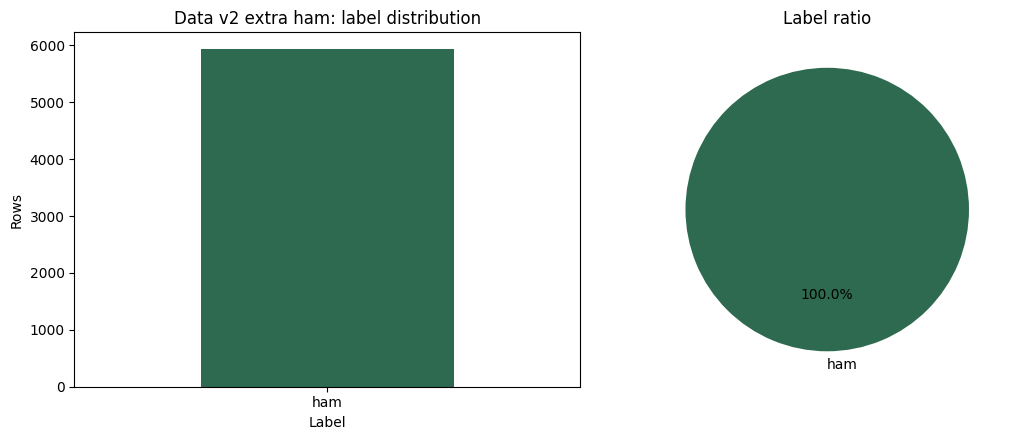

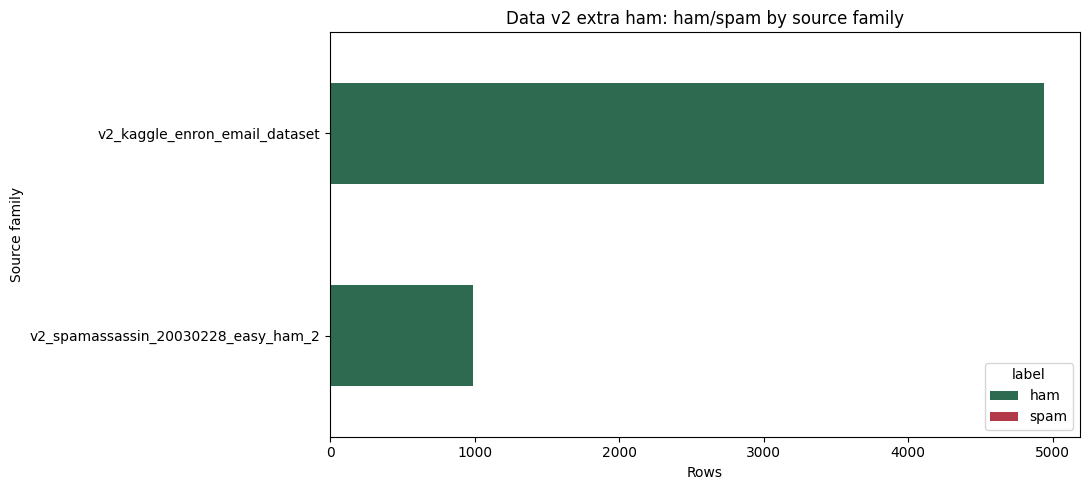

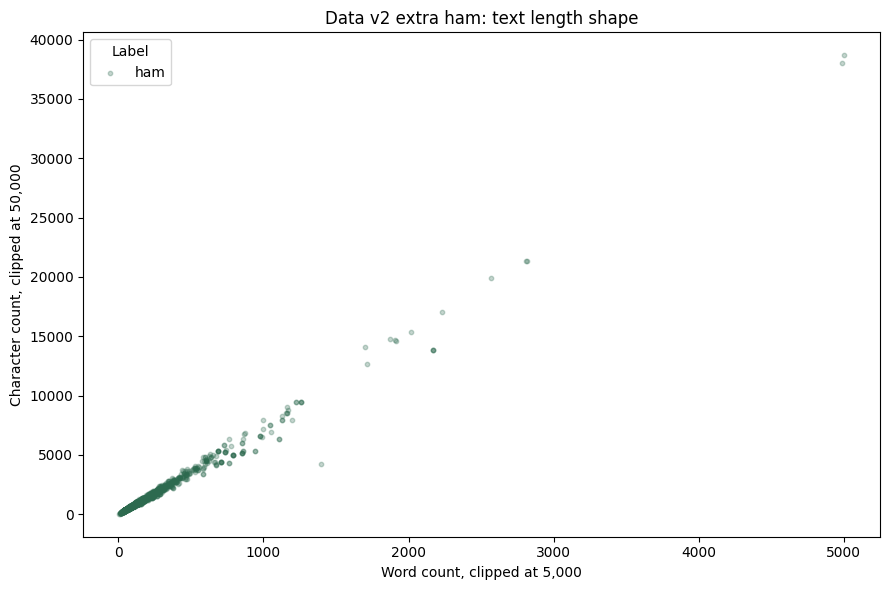

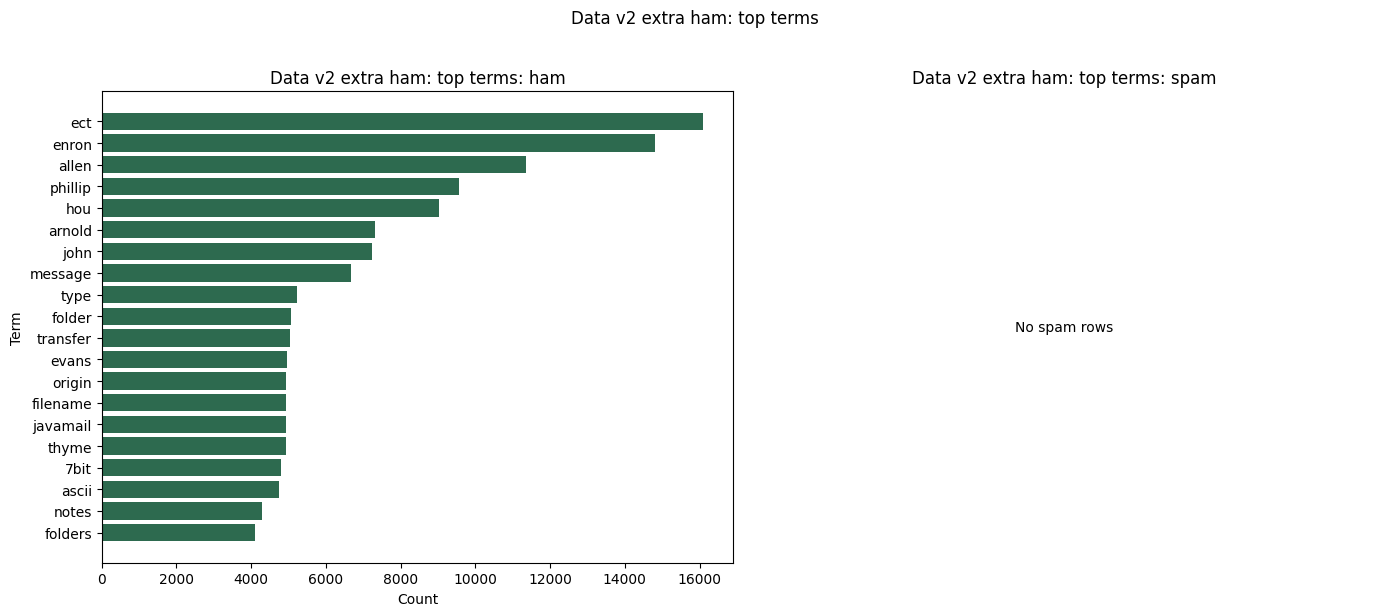

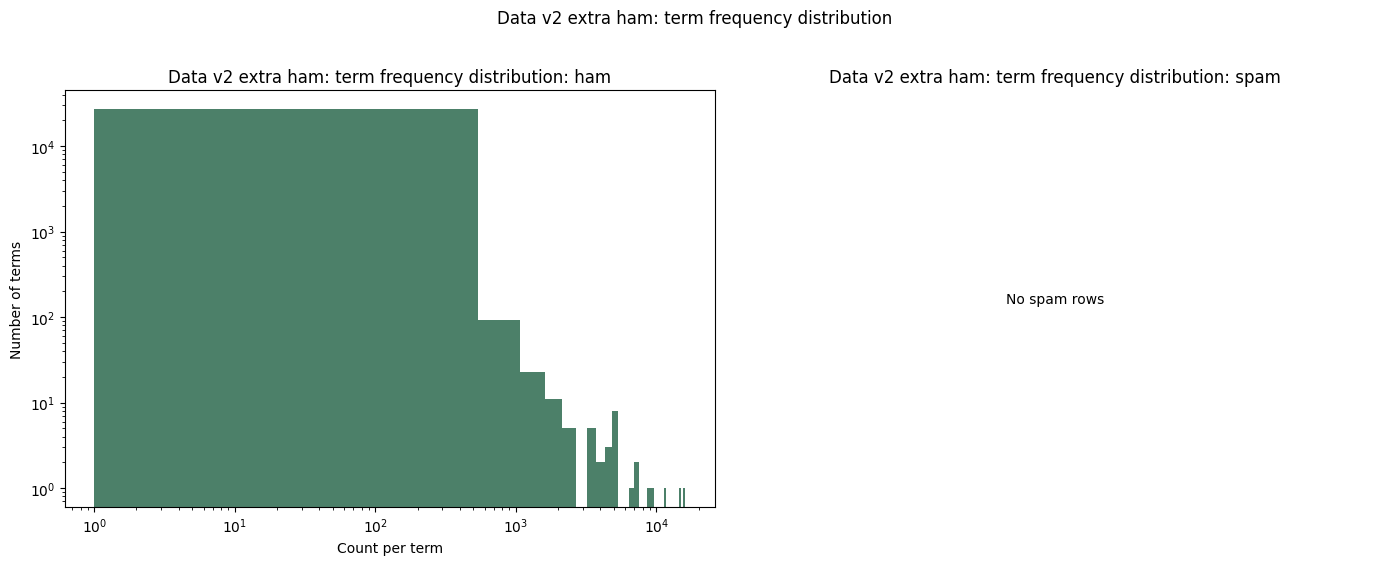

In [46]:
data_v2 = utils.load_and_show_data_v2(PROJECT_ROOT)

## Step 5 — Fixed Train/Test Split

Chia `processed_data` từ `data/processed/emails.csv` một lần để giữ đúng protocol đã dùng ở kết quả sát mục tiêu trước đó. Step 2 vẫn dùng `before_balance_data` để EDA unbalance; từ Step 5 trở đi dùng `processed_data` làm base so sánh model. Test set này được giữ cố định cho cả 3 phiên bản train.


In [47]:
split_context = utils.prepare_fixed_split(processed_data)
comparison_base_data = split_context.comparison_base_data
TEXT_COLUMN = split_context.text_column
base_train_data = split_context.base_train_data
base_test_data = split_context.base_test_data
train_data = split_context.train_data
test_data = split_context.test_data
x_train, y_train = split_context.x_train, split_context.y_train
x_test, y_test = split_context.x_test, split_context.y_test

Text column: clean_text


,split,rows,ham,spam
0,processed_base_train,7908,4345,3563
1,balanced_train_for_baseline,7126,3563,3563
2,fixed_processed_test,1978,1088,890


label,ham,spam
source_family,,
aueb_enron1_spam_ham,385,361
aueb_enron2_spam_ham,392,389
aueb_enron3_spam_ham,393,394
aueb_enron4_spam_ham,390,354
aueb_enron5_spam_ham,370,239
aueb_enron6_spam_ham,380,337
huggingface_enron_spam,304,321
huggingface_kimdongh_spam_dataset,374,356
kaggle_email_spam_classification,346,417


## Step 6 — Train 3 Data Versions And Draw 9 Confusion Matrices

Train 3 model trên 3 phiên bản training data, nhưng test trên cùng `fixed_processed_test`:

- `Balanced`: downsample từ `processed_base_train`.
- `Unbalanced`: giữ nguyên phân phối `processed_base_train`.
- `V2 merged`: `processed_base_train` + ham từ `data_v2`, sau khi loại mọi `clean_text` trùng với test.

Lưu ý: đây là evaluation ở threshold mặc định của model. Kết quả sát mục tiêu `TPR 99% / FPR 1%` nằm ở Step 13 vì Step 13 có tune threshold trên validation.


,dataset,rows,ham,spam,source_families
0,processed_base_train before mode transform,7908,4345,3563,11
1,data_v2 extra ham added to train only,5809,5809,0,2
2,V2 merged train,13236,9673,3563,13
3,fixed_processed_test,1978,1088,890,11


,training_mode,train_rows,ham_train,spam_train,source_families
0,Balanced,7126,3563,3563,11
1,Unbalanced,7908,4345,3563,11
2,V2 merged,13236,9673,3563,13


label,ham,spam
source_family,,
aueb_enron1_spam_ham,385,361
aueb_enron2_spam_ham,392,389
aueb_enron3_spam_ham,393,394
aueb_enron4_spam_ham,390,354
aueb_enron5_spam_ham,370,239
aueb_enron6_spam_ham,380,337
huggingface_enron_spam,304,321
huggingface_kimdongh_spam_dataset,374,356
kaggle_email_spam_classification,346,417


,training_mode,model,train_rows,ham_train,spam_train,test_rows,ham_test,spam_test,TN,FP,FN,TP,accuracy,precision,recall,TPR,FPR,FNR,TNR
2,Balanced,Linear SVM,7126,3563,3563,1978,1088,890,1059,29,3,887,0.9838,0.9683,0.9966,0.9966,0.0267,0.0034,0.9733
1,Balanced,Logistic Regression,7126,3563,3563,1978,1088,890,1040,48,4,886,0.9737,0.9486,0.9955,0.9955,0.0441,0.0045,0.9559
0,Balanced,Naive Bayes,7126,3563,3563,1978,1088,890,1058,30,19,871,0.9752,0.9667,0.9787,0.9787,0.0276,0.0213,0.9724
5,Unbalanced,Linear SVM,7908,4345,3563,1978,1088,890,1075,13,4,886,0.9914,0.9855,0.9955,0.9955,0.0119,0.0045,0.9881
4,Unbalanced,Logistic Regression,7908,4345,3563,1978,1088,890,1064,24,11,879,0.9823,0.9734,0.9876,0.9876,0.0221,0.0124,0.9779
3,Unbalanced,Naive Bayes,7908,4345,3563,1978,1088,890,1082,6,46,844,0.9737,0.9929,0.9483,0.9483,0.0055,0.0517,0.9945
8,V2 merged,Linear SVM,13236,9673,3563,1978,1088,890,1082,6,16,874,0.9889,0.9932,0.9820,0.9820,0.0055,0.0180,0.9945
7,V2 merged,Logistic Regression,13236,9673,3563,1978,1088,890,1080,8,40,850,0.9757,0.9907,0.9551,0.9551,0.0074,0.0449,0.9926
6,V2 merged,Naive Bayes,13236,9673,3563,1978,1088,890,1088,0,232,658,0.8827,1.0000,0.7393,0.7393,0.0000,0.2607,1.0000


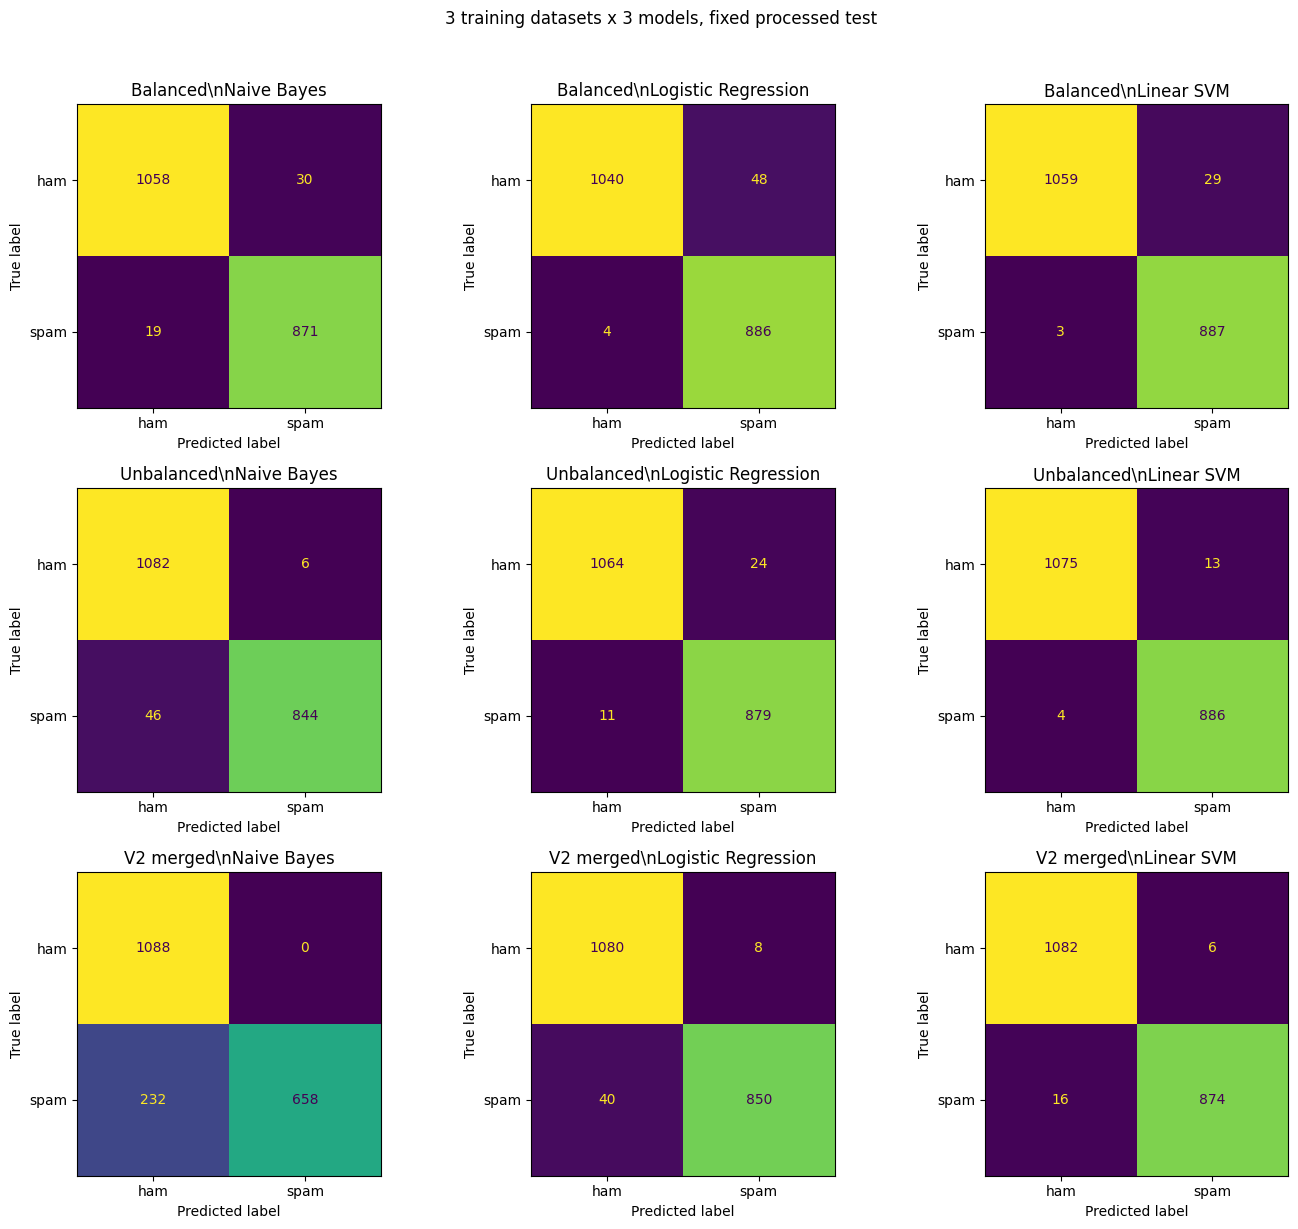

In [48]:
three_data_context = utils.run_three_data_model_comparison(split_context, data_v2, model_checker)
train_modes_3data = three_data_context["train_modes"]
v2_merged_train = three_data_context["v2_merged_train"]
results_9matrix = three_data_context["results"]
matrices_9 = three_data_context["matrices"]

## Step 7 — Feature Engineering: TF-IDF


In [49]:
tfidf_shape, tfidf_features = model_checker.tfidf_feature_preview(x_train, preview_count=30)

print(f"TF-IDF matrix shape: {tfidf_shape[0]:,} emails x {tfidf_shape[1]:,} features")
print("Example features:")
print(tfidf_features)

TF-IDF matrix shape: 7,126 emails x 138,942 features
Example features:
['000e' '000e mails' '00am' '00pm' '01pm' '06t18' '08pm' '0ne'
 '0ne million' '100k' '105th' '105th congress' '10acpi' '10acpi load'
 '10th' '11th' '11th floor' '11th larry' '11th meeting' '128mb'
 '128mb ram' '13th' '13th closing' '14th' '15pm' '16th' '16th january'
 '18th' '18th thanks' '192mb']


## Step 8 — Three Algorithms From Scratch + Sklearn Checker

Tự code 3 thuật toán: Multinomial Naive Bayes, Logistic Regression, Linear SVM. Lớp `SklearnModelChecker` train model tương ứng bằng sklearn để kiểm tra lại logic trên cùng sample.


### Step 8.1 — Build TF-IDF Matrix For Checking

Tạo một sample nhỏ hơn để 3 model from scratch chạy nhanh trong notebook. Cả 3 thuật toán dùng cùng một ma trận TF-IDF để so sánh công bằng.

In [50]:
scratch_context = utils.prepare_scratch_context(split_context, model_checker)
X_train_scratch = scratch_context.x_train_matrix
X_test_scratch = scratch_context.x_test_matrix
y_train_scratch = scratch_context.y_train
y_test_scratch = scratch_context.y_test

Scratch/check train matrix: (3000, 55476)
Scratch/check test matrix: (1000, 55476)


### Step 8.2 — Train Three Models From Scratch

Ba class dưới đây là code tự viết trong `model_from_scratch.py`: `ScratchMultinomialNB`, `ScratchLogisticRegression`, và `ScratchLinearSVM`.

,algorithm,class_called_in_notebook,scratch_accuracy
0,Multinomial Naive Bayes,ScratchMultinomialNB,0.965
1,Logistic Regression,ScratchLogisticRegression,0.923
2,Linear SVM,ScratchLinearSVM,0.960


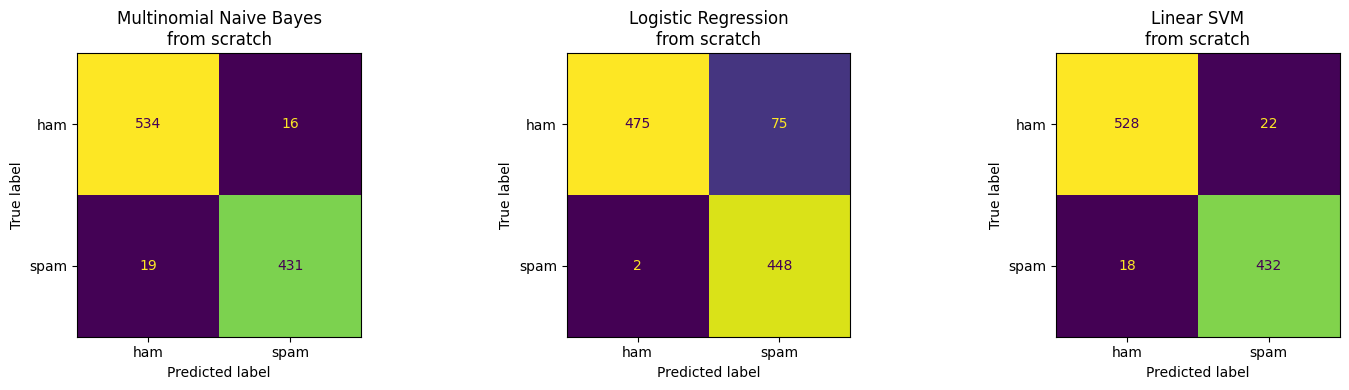

In [51]:
scratch_results = utils.train_scratch_models(scratch_context)
scratch_models = scratch_results["models"]
scratch_predictions_by_model = scratch_results["predictions_by_model"]
scratch_summary = scratch_results["summary"]

### Step 8.3 — Double Check With Sklearn


In [52]:
model_check_differences = utils.compare_scratch_with_sklearn(scratch_context, scratch_results)

,algorithm,scratch_accuracy,sklearn_accuracy,accuracy_diff_abs,prediction_disagreement_rate,mismatch_count,checked_rows
0,Multinomial Naive Bayes,0.965,0.965,0.000,0.000,0,1000
1,Logistic Regression,0.923,0.964,0.041,0.043,43,1000
2,Linear SVM,0.960,0.981,0.021,0.037,37,1000


## Step 9 — Baseline Model Training


In [53]:
model, predictions, baseline_accuracy, model_accuracy = model_checker.train_project_model(x_train, y_train, x_test, y_test)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Naive Bayes accuracy: {model_accuracy:.4f}")

Baseline accuracy: 0.5501
Naive Bayes accuracy: 0.9752


## Step 10 — Baseline Evaluation


              precision    recall  f1-score   support

         ham       0.98      0.97      0.98      1088
        spam       0.97      0.98      0.97       890

    accuracy                           0.98      1978
   macro avg       0.97      0.98      0.98      1978
weighted avg       0.98      0.98      0.98      1978



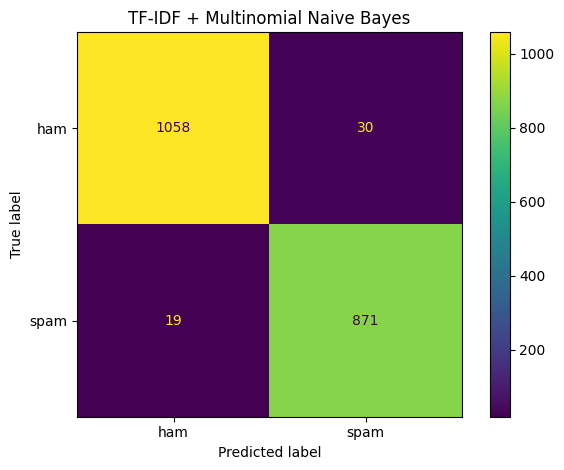

In [54]:
print(eda.classification_report_text(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("TF-IDF + Multinomial Naive Bayes")
plt.tight_layout()
plt.show()

### Step 10 Notes — Reading The Metrics

In [55]:
display(eda.top_tokens(model, top_n=15))

label,ham,spam
rank,,
1,enron,free
2,ect,money
3,hou,online
4,hou ect,information
5,thanks,best
6,ect ect,new
7,pm,mail
8,know,time
9,attached,want


In [56]:
display(eda.per_source_scores(test_data, predictions).head(15))

,source_family,rows,accuracy,macro_precision,macro_recall,macro_f1
10,spamassassin,267,0.898876,0.889025,0.913688,0.895201
8,kaggle_email_spam_classification,191,0.931937,0.930930,0.934939,0.931667
6,huggingface_enron_spam,156,0.987179,0.987171,0.987171,0.987171
2,aueb_enron3_spam_ham,198,0.989899,0.990099,0.989899,0.989898
4,aueb_enron5_spam_ham,152,0.993421,0.994624,0.991667,0.993096
5,aueb_enron6_spam_ham,179,0.994413,0.994118,0.994737,0.994396
7,huggingface_kimdongh_spam_dataset,183,0.994536,0.994737,0.994382,0.994530
3,aueb_enron4_spam_ham,186,0.994624,0.994949,0.994318,0.994605
1,aueb_enron2_spam_ham,195,0.994872,0.994898,0.994898,0.994872
0,aueb_enron1_spam_ham,187,1.000000,1.000000,1.000000,1.000000


## Step 11 — Cross-Source Holdout Check

In [57]:
display(eda.cross_source_holdout(before_balance_data, TEXT_COLUMN, paths["metrics_dir"]).head(15))

,holdout_source,rows,labels,accuracy,macro_f1
0,spamassassin_20021010_hard_ham,66,ham,0.257576,0.409639
1,spamassassin_20021010_easy_ham,101,ham,0.653465,0.790419
2,spamassassin_20030228_easy_ham,71,ham,0.690141,0.816667
3,kaggle_email_spam_classification,795,"ham,spam",0.905660,0.891409
5,huggingface_enron_spam,652,"ham,spam",0.972393,0.970670
6,aueb_enron4_spam_ham,693,"ham,spam",0.974026,0.971640
7,aueb_enron6_spam_ham,672,"ham,spam",0.974702,0.972724
8,aueb_enron1_spam_ham,705,"ham,spam",0.975887,0.973683
9,huggingface_kimdongh_spam_dataset,694,"ham,spam",0.982709,0.981308
11,aueb_enron2_spam_ham,737,"ham,spam",0.985075,0.983369


## Step 12 — Optional Model Comparison

In [58]:
display(model_checker.compare_models(before_balance_data, TEXT_COLUMN, sample_rows=50_000))

,model,accuracy,macro_precision,macro_recall,macro_f1
2,Linear SVM,0.980324,0.977928,0.979477,0.978694
1,Logistic Regression,0.967593,0.968927,0.960642,0.964544
0,Naive Bayes,0.928627,0.948917,0.901431,0.918718


## Step 13 — Validation-Tuned Threshold For Balanced / Unbalanced / V2

Dùng cùng base `processed_data` với Step 6 nhưng tách thêm validation set. Threshold chỉ được chọn trên validation với ràng buộc `FPR <= 1%`, sau đó báo cáo kết quả cuối trên fixed test set. Đây là step cần nhìn khi hỏi model nào sát mục tiêu `TPR 99% / FPR 1%`.


Thresholds are selected on validation only; final metrics are evaluated on test only.


,split,rows,ham,spam
0,train_pool_base,5931,3259,2672
1,data_v2_extra_train_only,5705,5705,0
2,validation,1977,1086,891
3,test,1978,1088,890


,training_strategy,train_rows,ham_train,spam_train,source_families
0,Balanced,5344,2672,2672,11
1,Unbalanced,5931,3259,2672,11
2,V2 merged,11259,8587,2672,13


,training_strategy,model,score_type,train_rows,ham_train,spam_train,selected_threshold,validation_FPR,validation_TPR,validation_AUC,...,FP,FN,TP,accuracy,precision,TPR,FPR,FNR,balanced_accuracy,can_reach_99_1_on_validation
6,V2 merged,Naive Bayes,probability,11259,8587,2672,0.1210,0.0092,0.9304,0.9968,...,6,79,811,0.9570,0.9927,0.9112,0.0055,0.0888,0.9529,False
5,Unbalanced,Linear SVM (Calibrated),probability,5931,3259,2672,0.4909,0.0092,0.9955,0.9998,...,14,14,876,0.9858,0.9843,0.9843,0.0129,0.0157,0.9857,True
7,V2 merged,Logistic Regression,probability,11259,8587,2672,0.4428,0.0074,0.9865,0.9995,...,14,27,863,0.9793,0.9840,0.9697,0.0129,0.0303,0.9784,False
1,Balanced,Logistic Regression,probability,5344,2672,2672,0.6171,0.0092,0.9776,0.9991,...,14,38,852,0.9737,0.9838,0.9573,0.0129,0.0427,0.9722,False
2,Balanced,Linear SVM (Calibrated),probability,5344,2672,2672,0.6365,0.0092,0.9921,0.9996,...,15,20,870,0.9823,0.9831,0.9775,0.0138,0.0225,0.9819,True
3,Unbalanced,Naive Bayes,probability,5931,3259,2672,0.3818,0.0083,0.9910,0.9996,...,15,29,861,0.9778,0.9829,0.9674,0.0138,0.0326,0.9768,True
4,Unbalanced,Logistic Regression,probability,5931,3259,2672,0.5436,0.0064,0.9865,0.9995,...,16,33,857,0.9752,0.9817,0.9629,0.0147,0.0371,0.9741,False
0,Balanced,Naive Bayes,probability,5344,2672,2672,0.5648,0.0092,0.9764,0.9992,...,17,31,859,0.9757,0.9806,0.9652,0.0156,0.0348,0.9748,False
8,V2 merged,Linear SVM (Calibrated),probability,11259,8587,2672,0.3378,0.0092,0.9978,0.9998,...,20,11,879,0.9843,0.9778,0.9876,0.0184,0.0124,0.9846,True


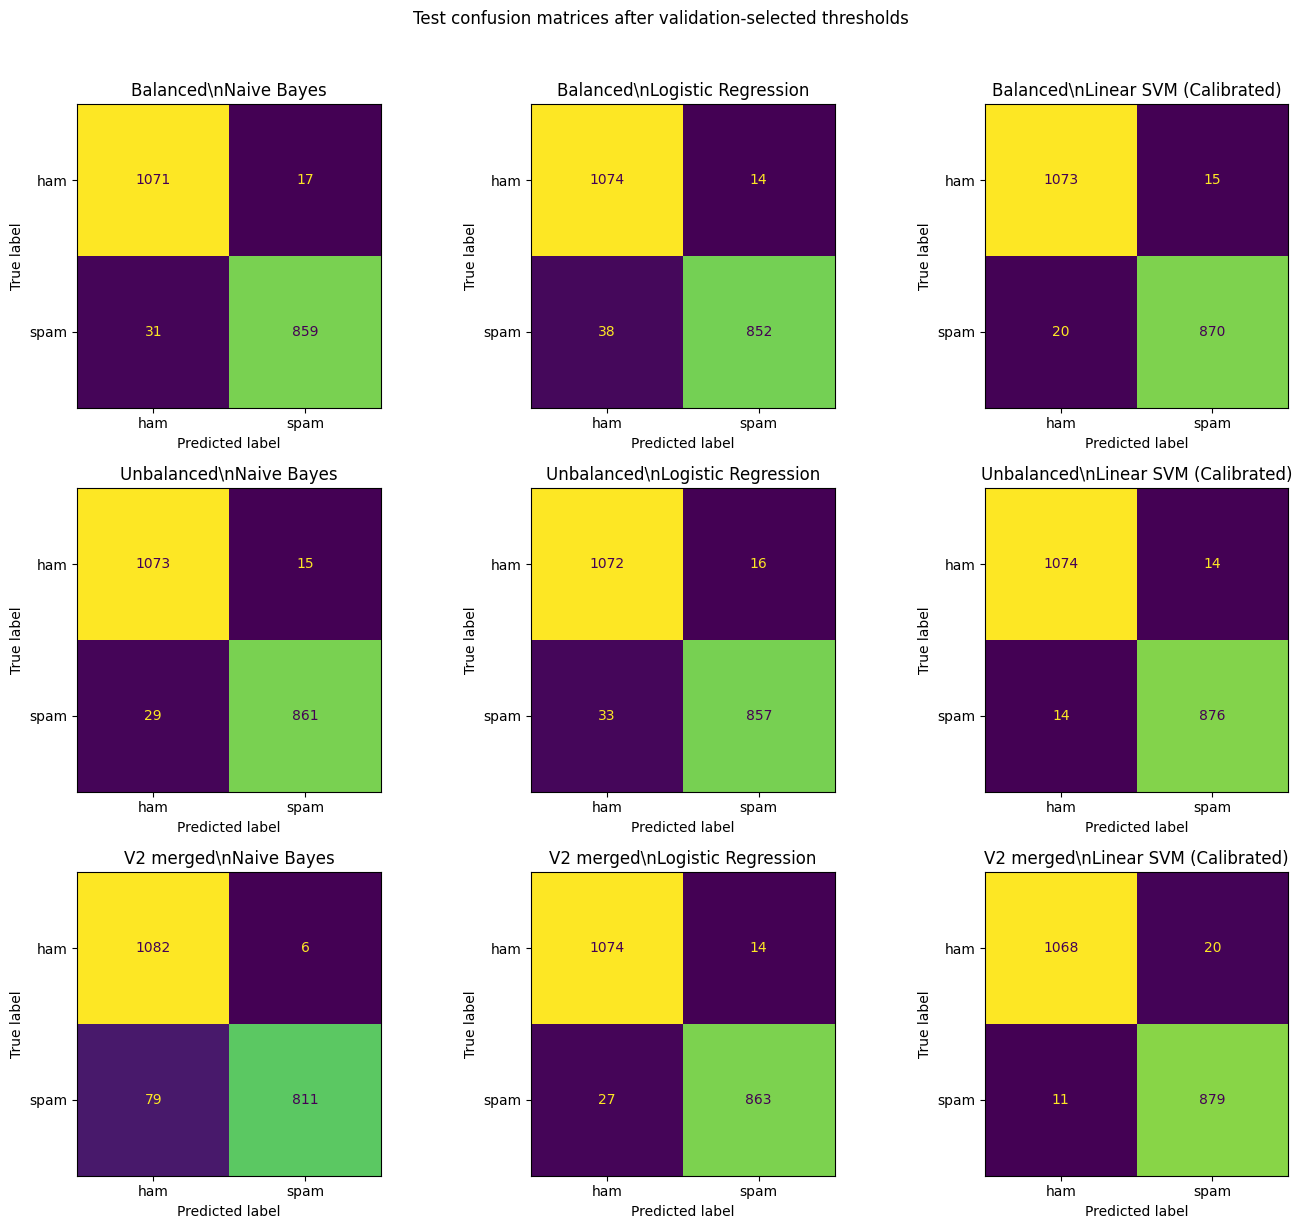

Validation-selected candidate: V2 merged / Linear SVM (Calibrated) -> validation TPR=0.9978, validation FPR=0.0092; test TPR=0.9876, test FPR=0.0184, threshold=0.3378
Diagnostic only - best observed test TPR with test FPR <= 1%: V2 merged / Naive Bayes -> TPR=0.9112, FPR=0.0055, threshold=0.1210
No validation-tuned model reaches TPR >= 99% and FPR <= 1% on test; the target still requires stronger features/model or more data quality work.


In [59]:
TARGET_FPR = 0.01
TARGET_TPR = 0.99
positive_label = "spam"
negative_label = "ham"
matrix_labels = [negative_label, positive_label]

threshold_context = utils.run_threshold_tuning(
    processed_data,
    data_v2,
    model_checker,
    target_fpr=TARGET_FPR,
    target_tpr=TARGET_TPR,
    positive_label=positive_label,
    negative_label=negative_label,
)
threshold_results = threshold_context["threshold_results"]
validation_roc_curves = threshold_context["validation_roc_curves"]
confusion_matrices = threshold_context["confusion_matrices"]
threshold_specs = threshold_context["threshold_specs"]
validation_choice = threshold_context["validation_choice"]
threshold_text_column = threshold_context["text_column"]
train_pool = threshold_context["train_pool"]
validation_frame = threshold_context["validation_frame"]
threshold_test_frame = threshold_context["test_frame"]
threshold_train_modes = threshold_context["train_modes"]

## Step 14 — Low-FPR ROC View

Zoom vào vùng FPR thấp để xem model nào giữ được false positive thấp nhất trong khi tăng TPR.

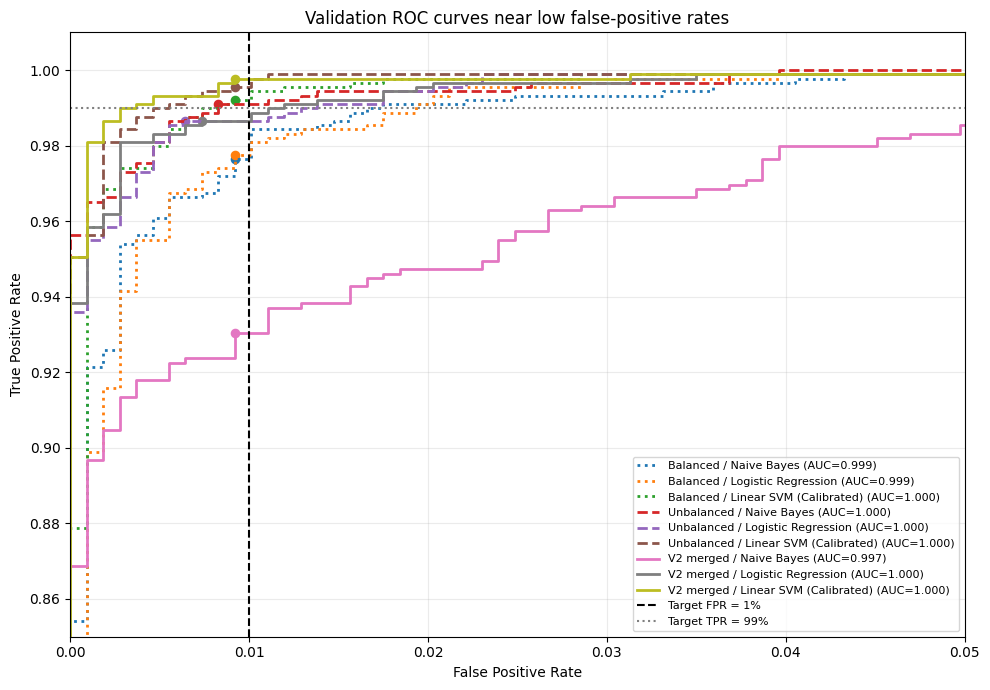

FPR                           TPR             \
training_strategy       Balanced Unbalanced V2 merged Balanced Unbalanced   
model                                                                       
Linear SVM (Calibrated)   0.0138     0.0129    0.0184   0.9775     0.9843   
Logistic Regression       0.0129     0.0147    0.0129   0.9573     0.9629   
Naive Bayes               0.0156     0.0138    0.0055   0.9652     0.9674   

                                  balanced_accuracy                       \
training_strategy       V2 merged          Balanced Unbalanced V2 merged   
model                                                                      
Linear SVM (Calibrated)    0.9876            0.9819     0.9857    0.9846   
Logistic Regression        0.9697            0.9722     0.9741    0.9784   
Naive Bayes                0.9112            0.9748     0.9768    0.9529   

                        precision                       
training_strategy        Balanced Unbalanced V2 merged  
model                                                   
Linear SVM (Calibrated)    0.9831     0.9843    0.9778  
Logistic Regression        0.9838     0.9817    0.9840  
Naive Bayes                0.9806     0.9829    0.9927

In [60]:
threshold_strategy_compare = utils.plot_low_fpr_roc(threshold_context)

## Step 15 — Data Failure Analysis For 99/1 Target

Chẩn đoán vì sao model chưa đạt đồng thời `TPR >= 99%` và `FPR <= 1%`. Phần này dùng model được chọn bằng validation, sau đó chỉ phân tích lỗi trên test.

Failure analysis model: V2 merged / Linear SVM (Calibrated) with threshold=0.3378, score_type=probability


,source_profile,sources,rows,ham,spam
0,mixed,10,12960,8291,4669


label,source_family,ham,spam,total,spam_rate,source_profile
9,spamassassin,4091,668,4759,0.140366,mixed
2,aueb_enron3_spam_ham,493,494,987,0.500507,mixed
8,kaggle_email_spam_classification,437,547,984,0.555894,mixed
1,aueb_enron2_spam_ham,490,488,978,0.498978,mixed
0,aueb_enron1_spam_ham,491,456,947,0.481521,mixed
3,aueb_enron4_spam_ham,492,444,936,0.474359,mixed
7,huggingface_kimdongh_spam_dataset,471,446,917,0.486369,mixed
5,aueb_enron6_spam_ham,480,423,903,0.468439,mixed
6,huggingface_enron_spam,384,404,788,0.512690,mixed
4,aueb_enron5_spam_ham,462,299,761,0.392904,mixed


,source_family,rows,ham_rows,spam_rows,FP,FN,TP,TN,FPR,FNR,TPR
10,spamassassin,267,169,98,9,2,96,160,0.0533,0.0204,0.9796
8,kaggle_email_spam_classification,191,86,105,3,7,98,83,0.0349,0.0667,0.9333
3,aueb_enron4_spam_ham,186,98,88,3,0,88,95,0.0306,0.0000,1.0000
5,aueb_enron6_spam_ham,179,95,84,2,0,84,93,0.0211,0.0000,1.0000
7,huggingface_kimdongh_spam_dataset,183,94,89,1,1,88,93,0.0106,0.0112,0.9888
2,aueb_enron3_spam_ham,198,99,99,1,0,99,98,0.0101,0.0000,1.0000
4,aueb_enron5_spam_ham,152,92,60,1,0,60,91,0.0109,0.0000,1.0000
1,aueb_enron2_spam_ham,195,98,97,0,1,96,98,0.0000,0.0103,0.9897
0,aueb_enron1_spam_ham,187,97,90,0,0,90,97,0.0000,0.0000,1.0000
6,huggingface_enron_spam,156,76,80,0,0,80,76,0.0000,0.0000,1.0000


,label,rows,near_threshold_rows,near_threshold_rate,score_min,score_median,score_max
0,ham,1088,8,0.0074,0.0000,0.0001,0.8757
1,spam,890,5,0.0056,0.0694,0.9998,1.0000


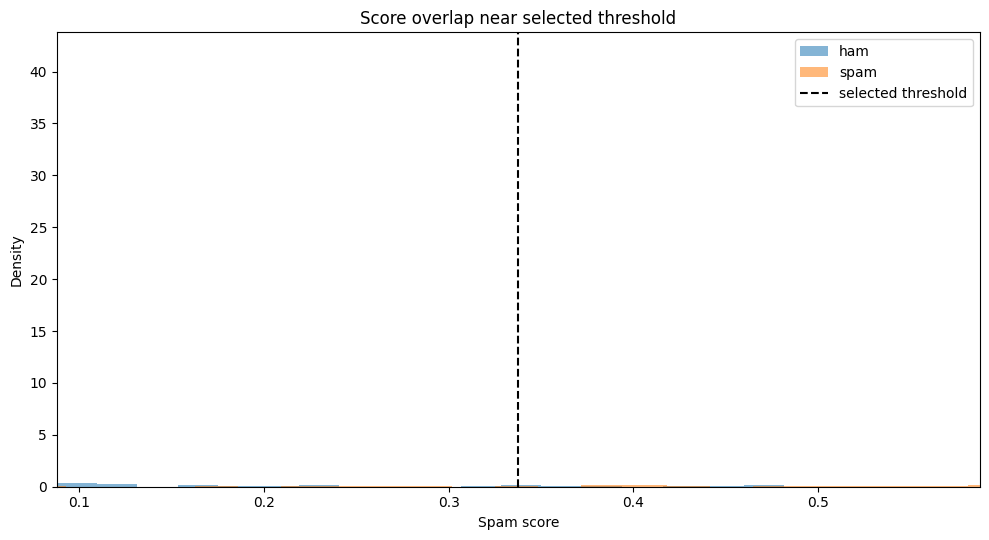

False positives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
414,FP,ham,spam,0.3391,0.0013,aueb_enron3_spam_ham,hanover,hanover hanover stock price closed today recen...
1016,FP,ham,spam,0.3424,0.0046,kaggle_email_spam_classification,,bignum entirely unused builds just fine lint e...
1369,FP,ham,spam,0.3579,0.0201,aueb_enron4_spam_ham,yummy frappachino,yummy frappachino hey coffee really fun awake ...
1952,FP,ham,spam,0.3589,0.0211,aueb_enron6_spam_ham,anadarko and union pacific resources merged co...,anadarko union pacific resources merged compan...
680,FP,ham,spam,0.3914,0.0536,aueb_enron4_spam_ham,* information only * work on the floor tonight,information work floor tonight tonight having ...
1605,FP,ham,spam,0.4205,0.0827,spamassassin,"Re: Adam dont job for no one, see.",adam dont job wed sep tom wrote groys gesheft ...
930,FP,ham,spam,0.4271,0.0893,spamassassin,More Freebies with Ryanair.com,freebies ryanair extended free seat sale thurs...
929,FP,ham,spam,0.4488,0.1110,spamassassin,Bike Bits,bike bits fantastically bizarre device seen fl...
1282,FP,ham,spam,0.4598,0.1220,spamassassin,Recommended Viewing,recommended viewing watched lathe heaven pm ed...
1191,FP,ham,spam,0.4605,0.1227,spamassassin,"GAMESPOT PC: Lionheart designer diary, No One ...",gamespot pc lionheart designer diary lives for...


False negatives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
775,FN,spam,ham,0.3349,0.0029,kaggle_email_spam_classification,,attach awarego hell disciplin going im going w...
582,FN,spam,ham,0.3347,0.0031,kaggle_email_spam_classification,,check list known reason regulators mitigate ri...
877,FN,spam,ham,0.3018,0.0360,aueb_enron2_spam_ham,75 % reduction in road accidents,reduction road accidents august dear sir madam...
1078,FN,spam,ham,0.2801,0.0577,huggingface_kimdongh_spam_dataset,,leasing deal year mercedes benz elegance auto ...
1832,FN,spam,ham,0.2667,0.0711,spamassassin,Unleash your PC's Multimedia POWER at 70% off ...,unleash pc's multimedia power retail
983,FN,spam,ham,0.2514,0.0864,kaggle_email_spam_classification,,range crown papers definition principal annual...
576,FN,spam,ham,0.2494,0.0884,kaggle_email_spam_classification,,fleming nov simulate clicking trigger user ope...
384,FN,spam,ham,0.2214,0.1164,kaggle_email_spam_classification,,attached image metar hk dont want nervous conn...
881,FN,spam,ham,0.1823,0.1555,kaggle_email_spam_classification,,message celebrate summer cases favorite soda adf
424,FN,spam,ham,0.0738,0.2640,spamassassin,"Invite: Content Management Summit, Oct. 10th N...",invite management summit oct 10th new york city


,rows,labels,sources,text_preview
7544,2,"ham,spam",spamassassin,mv mv mv mv mv mv mv mv mv mv mv mv mv mv mv m...


,error_type,token,count
0,FP,aids,15
1,FP,free,14
2,FP,2c,13
3,FP,price,13
4,FP,merck,12
5,FP,company,11
6,FP,rh,11
7,FP,brazil,10
8,FP,mail,10
9,FP,8c,10


,issue,evidence,impact,next_action
0,Source-label confounding,0 ham-only source families with 0 rows; source...,Model can learn source/domain style instead of...,"Evaluate by source family, reduce source artif..."
1,Score overlap around threshold,Near threshold (+/-0.05): 8 ham and 5 spam rows.,Raising TPR pulls overlapping ham across thres...,Add stronger features such as URL/header/domai...
2,False positives / false negatives are source-p...,"Top source errors include spamassassin, kaggle...",Some sources dominate residual errors; global ...,"Inspect source-specific samples, label noise, ..."
3,Exact conflicting clean_text labels,1 conflicting clean_text groups shown; total d...,"If conflicts exist, no threshold can classify ...",Deduplicate/resolve conflicting labels before ...
4,Token/artifact-driven errors,FP/FN top-token tables show the words most ass...,TF-IDF may be reacting to artifacts rather tha...,Extend cleaning and add robust non-text featur...


In [61]:
failure_context = utils.run_failure_analysis(threshold_context, before_balance_data, model_checker)
analysis_choice = failure_context["analysis_choice"]
analysis_errors = failure_context["analysis_errors"]
analysis_metrics = failure_context["analysis_metrics"]
source_confounding = failure_context["source_confounding"]
source_profile_summary = failure_context["source_profile_summary"]
source_errors = failure_context["source_errors"]
overlap_summary = failure_context["overlap_summary"]
conflicts = failure_context["conflicts"]
error_tokens = failure_context["error_tokens"]
issue_summary = failure_context["issue_summary"]

## Step 16 — Save And Reuse The Model

In [62]:
saved_model_path = model_checker.save_model(model, paths["model"])
print(f"Saved model to {saved_model_path.relative_to(PROJECT_ROOT)}")

Saved model to models/spam_nb.joblib


In [63]:
display(model_checker.predict_new_emails(paths["model"]))

,email_text,clean_text,prediction,confidence
0,Win cash now! Click the prize link and claim y...,win cash prize link claim bonus today,spam,0.8824
1,"Hi team, attached are the meeting notes and ne...",hi team attached meeting notes steps today's p...,ham,0.9455


## Step 17 — Project Reports

In [64]:
display(crawl.report_status(paths["metrics_dir"], PROJECT_ROOT))

print("\nSaved classification report:\n")
print(crawl.read_classification_report(paths["metrics_dir"]))

,report,status
0,data/processed/metrics/preprocessing_balance_r...,exists
1,data/processed/metrics/classification_report.txt,exists
2,data/processed/metrics/model_summary.md,exists
3,data/processed/metrics/per_source_classificati...,exists
4,data/processed/metrics/cross_source_holdout_re...,exists



Saved classification report:

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       896
        spam       0.98      0.98      0.98       892

    accuracy                           0.98      1788
   macro avg       0.98      0.98      0.98      1788
weighted avg       0.98      0.98      0.98      1788

